# Clacular factores de horas pico durante los periodos de viaje

In [81]:
import pandas as pd
import geopandas as gpd
import numpy as np
import os
import matplotlib.pyplot as plt
from matplotlib.patches import Patch


In [82]:
PATH = r"C:\proyectos\red-vial-guadalajara\OneDrive_2026-08-25"
FOLDER_MATRIZ = r"Insumos IMEPLAN\Matriz Origen Destino"
FOLDER_ZONAS = r"red_shapefiles\zones_agebs_visum"

In [83]:
matriz_global = pd.read_excel(os.path.join(PATH, FOLDER_MATRIZ, "matriz_origen_destino_agebs_por_hora.xlsx"))
matriz_global.head()

,Modo,Hora_inicio,Origen,Destino,Ponderador
0,Transporte Público,0,140980243,1407000211185,9
1,Transporte Público,0,1403900012588,1403900014014,125
2,Transporte Público,0,1403900012624,1403900012639,136
3,Transporte Público,0,1403900012639,1403900012624,136
4,Transporte Público,0,1403900013406,1403900015474,125


In [84]:
print("Filas:", len(matriz_global))


Filas: 74643


Le agregamos a la matriz las nuevas columnas de origen y destino con distinto ID

In [85]:
zones_standarized = gpd.read_file(os.path.join(PATH, FOLDER_ZONAS, "zonas_agebs_standarized.shp"))


In [86]:
zones_standarized.head()

,clave_ageb,clave_enti,clave_muni,clave_loca,ageb,nombre_mun,tipo_ageb,poblacion_,area_m2,area_km2,establecim,empleados_,densidad_p,densidad_e,densidad_1,distancia_,consecutiv,id_mun_age,geometry
0,1403900010026,14,39,1,0026,Guadalajara,urbano,1433,4.719139e+05,0.471914,67,1529.814941,3036.571136,141.975064,3241.724978,5.583186,1,1,"POLYGON ((2356822.264 967782.506, 2356822.889 ..."
1,1403900010030,14,39,1,0030,Guadalajara,urbano,3440,1.612152e+06,1.612152,331,14409.866313,2133.793827,205.315627,8938.280170,4.470820,2,2,"POLYGON ((2357908.827 968014.844, 2357908.762 ..."
2,140390001005A,14,39,1,005A,Guadalajara,urbano,1538,1.953332e+05,0.195333,93,1548.060105,7873.724252,476.109464,7925.226524,4.270276,3,3,"POLYGON ((2358490.603 967128.043, 2358482.881 ..."
3,1403900010064,14,39,1,0064,Guadalajara,urbano,2647,3.432409e+05,0.343241,89,527.716337,7711.784729,259.293102,1537.451754,3.822108,4,4,"POLYGON ((2359338.344 967381.133, 2359338.498 ..."
4,1403900010083,14,39,1,0083,Guadalajara,urbano,5123,3.357561e+05,0.335756,127,502.873311,15258.100466,378.250783,1497.734043,4.144958,5,5,"POLYGON ((2360101.9 968343.665, 2360092.864 96..."


In [87]:
dicc = dict(zip(zones_standarized["clave_ageb"].astype(str),
                zones_standarized["id_mun_age"]))

In [88]:
matriz_global["Origen_ageb"]  = matriz_global["Origen"].astype(str).map(dicc)
matriz_global["Destino_ageb"] = matriz_global["Destino"].astype(str).map(dicc)

matriz_global.head(10)

,Modo,Hora_inicio,Origen,Destino,Ponderador,Origen_ageb,Destino_ageb
0,Transporte Público,0,140980243,1407000211185,9,6237.0,3094.0
1,Transporte Público,0,1403900012588,1403900014014,125,212.0,288.0
2,Transporte Público,0,1403900012624,1403900012639,136,216.0,217.0
3,Transporte Público,0,1403900012639,1403900012624,136,217.0,216.0
4,Transporte Público,0,1403900013406,1403900015474,125,241.0,422.0
5,Transporte Público,0,1403900014014,1403900012588,125,288.0,212.0
6,Transporte Público,0,1403900014048,140390001350A,125,291.0,243.0
7,Transporte Público,0,1403900014298,1403900014300,131,315.0,316.0
8,Transporte Público,0,1403900014300,1403900014298,131,316.0,315.0
9,Transporte Público,0,1403900015065,141010001019A,131,383.0,7003.0


In [89]:
print(matriz_global.loc[matriz_global["Origen_ageb"].isna(), "Origen"].unique())


[999990004 '99999000A' 999990003 999990005 999990006 999990001 999990002]


In [90]:
print("Número de filas:", len(matriz_global))
print("Celdas NaN en Origen_ageb:", matriz_global["Origen_ageb"].isna().sum())
print("Celdas NaN en Destino_ageb:", matriz_global["Destino_ageb"].isna().sum())

Número de filas: 74643
Celdas NaN en Origen_ageb: 1097
Celdas NaN en Destino_ageb: 1071


De momento hay celdas con NaN en las columnas de Origen_ageb y Destino_ageb, se van a arreglar con el diccionario de las 7 variables que no están empatadas aún con id_mun_age

Con base en el diccionario anterior, se agrega la clasificación del periodo del día con base en la hora

| Period Code | Period Name | Start Hour | End Hour |
|--------------|----------|-------|-------|
| EM | Early Morning    | 00:00 | 03:59 |
| AP | AM Peak          | 04:00 | 08:59 |
| LM | Late Morning     | 9:00  | 11:59 |
| EA | Early Afternoon  | 12:00 | 17:59 |
| PP | PM Peak          | 18:00 | 20:59 |
| LN | Late Night       | 21:00 | 23:59 |


In [91]:
def asignar_periodo(h):
    if 0 <= h <= 3:
        return "EM"
    elif 4 <= h <= 8:
        return "AP"
    elif 9 <= h <= 11:
        return "LM"
    elif 12 <= h <= 17:
        return "EA"
    elif 18 <= h <= 20:
        return "PP"
    elif 21 <= h <= 23:
        return "LN"

In [92]:
matriz_global["Periodo"] = matriz_global["Hora_inicio"].apply(asignar_periodo)
matriz_global.head()

,Modo,Hora_inicio,Origen,Destino,Ponderador,Origen_ageb,Destino_ageb,Periodo
0,Transporte Público,0,140980243,1407000211185,9,6237.0,3094.0,EM
1,Transporte Público,0,1403900012588,1403900014014,125,212.0,288.0,EM
2,Transporte Público,0,1403900012624,1403900012639,136,216.0,217.0,EM
3,Transporte Público,0,1403900012639,1403900012624,136,217.0,216.0,EM
4,Transporte Público,0,1403900013406,1403900015474,125,241.0,422.0,EM


## Análisis de EM: Early Morning

In [93]:
em = matriz_global[matriz_global["Periodo"] == "EM"]

suma_por_hora_em = em.groupby("Hora_inicio")["Ponderador"].sum()
em_total = suma_por_hora_em.sum()
print("Total de viajes en EM:", em_total)
print(suma_por_hora_em)
em_peak = suma_por_hora_em.idxmax()
em_peak_value = suma_por_hora_em.max()

print("Hora pico: ", em_peak,", con ", em_peak_value, "  viajes.")

Total de viajes en EM: 40261
Hora_inicio
0    12571
1    10359
2     8014
3     9317
Name: Ponderador, dtype: int64
Hora pico:  0 , con  12571   viajes.


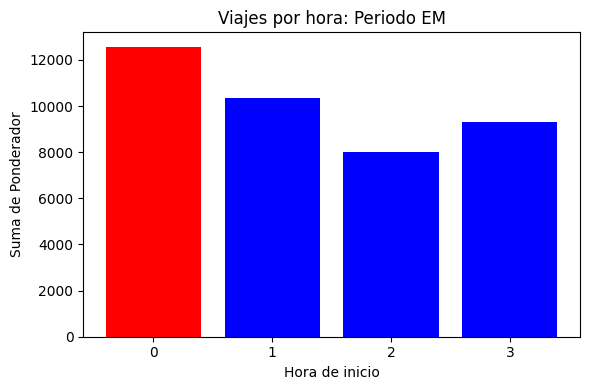

In [94]:
colores = ["red" if bar == em_peak else "blue" for bar in suma_por_hora_em.index]

plt.figure(figsize=(6, 4))
plt.bar(suma_por_hora_em.index.astype(str), suma_por_hora_em.values, color=colores)
plt.xlabel("Hora de inicio")
plt.ylabel("Suma de Ponderador")
plt.title("Viajes por hora: Periodo EM")
plt.tight_layout()
plt.show()

In [95]:
em_peak_factor = em_peak_value / em_total
print("peak factor de EM: ", em_peak_factor)

peak factor de EM:  0.3122376493380691


## Análisis de AP: AM Peak

In [96]:
ap = matriz_global[matriz_global["Periodo"] == "AP"]

suma_por_hora_ap = ap.groupby("Hora_inicio")["Ponderador"].sum()
ap_total = suma_por_hora_ap.sum()
print("Total de viajes en AP:", ap_total)
print(suma_por_hora_ap)
ap_peak = suma_por_hora_ap.idxmax()
ap_peak_value = suma_por_hora_ap.max()

print("Hora pico: ", ap_peak,", con ", ap_peak_value, "  viajes.")

Total de viajes en AP: 1713959
Hora_inicio
4     30296
5    159369
6    425937
7    616322
8    482035
Name: Ponderador, dtype: int64
Hora pico:  7 , con  616322   viajes.


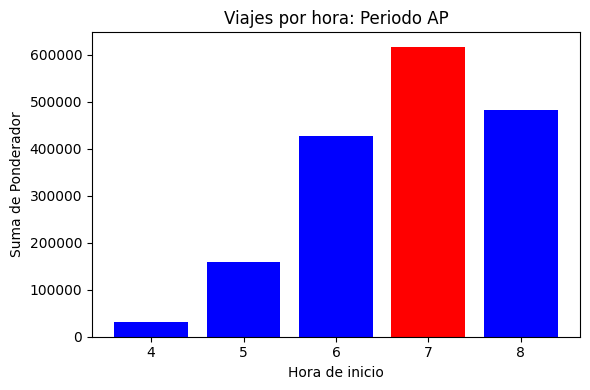

In [97]:
colores = ["red" if bar == ap_peak else "blue" for bar in suma_por_hora_ap.index]

plt.figure(figsize=(6, 4))
plt.bar(suma_por_hora_ap.index.astype(str), suma_por_hora_ap.values, color=colores)
plt.xlabel("Hora de inicio")
plt.ylabel("Suma de Ponderador")
plt.title("Viajes por hora: Periodo AP")
plt.tight_layout()
plt.show()

In [98]:
ap_peak_factor = ap_peak_value / ap_total
print("peak factor de AP: ", ap_peak_factor)

peak factor de AP:  0.3595896984700334


## Análisis de LM: Late Morning

In [99]:
lm = matriz_global[matriz_global["Periodo"] == "LM"]

suma_por_hora_lm = lm.groupby("Hora_inicio")["Ponderador"].sum()
lm_total = suma_por_hora_lm.sum()
print("Total de viajes en LM:", lm_total)
print(suma_por_hora_lm)
lm_peak = suma_por_hora_lm.idxmax()
lm_peak_value = suma_por_hora_lm.max()

print("Hora pico: ", lm_peak,", con ", lm_peak_value, "  viajes.")

Total de viajes en LM: 802885
Hora_inicio
9     300174
10    257466
11    245245
Name: Ponderador, dtype: int64
Hora pico:  9 , con  300174   viajes.


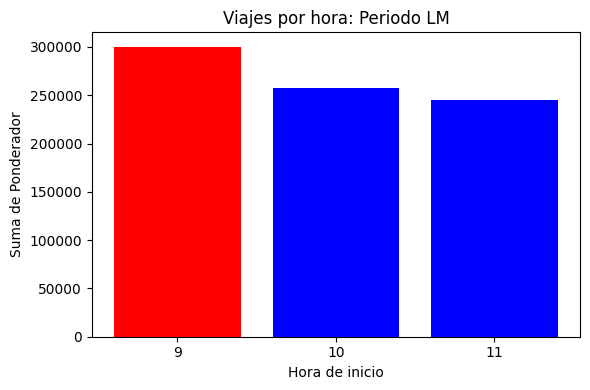

In [100]:
colores = ["red" if bar == lm_peak else "blue" for bar in suma_por_hora_lm.index]

plt.figure(figsize=(6, 4))
plt.bar(suma_por_hora_lm.index.astype(str), suma_por_hora_lm.values, color=colores)
plt.xlabel("Hora de inicio")
plt.ylabel("Suma de Ponderador")
plt.title("Viajes por hora: Periodo LM")
plt.tight_layout()
plt.show()

In [101]:
lm_peak_factor = lm_peak_value / lm_total
print("peak factor de LM: ", lm_peak_factor)

peak factor de LM:  0.3738692340746184


## Análisis de EA: Early Afternoon

In [102]:
ea = matriz_global[matriz_global["Periodo"] == "EA"]

suma_por_hora_ea = ea.groupby("Hora_inicio")["Ponderador"].sum()
ea_total = suma_por_hora_ea.sum()
print("Total de viajes en EA:", ea_total)
print(suma_por_hora_ea)
ea_peak = suma_por_hora_ea.idxmax()
ea_peak_value = suma_por_hora_ea.max()

print("Hora pico: ", ea_peak,", con ", ea_peak_value, "  viajes.")

Total de viajes en EA: 2374480
Hora_inicio
12    356953
13    431126
14    427048
15    367393
16    389080
17    402880
Name: Ponderador, dtype: int64
Hora pico:  13 , con  431126   viajes.


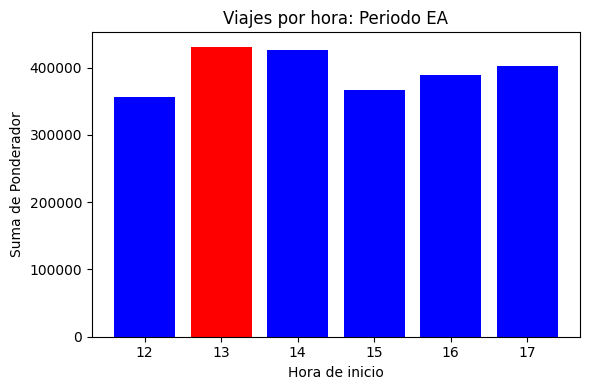

In [103]:
colores = ["red" if bar == ea_peak else "blue" for bar in suma_por_hora_ea.index]

plt.figure(figsize=(6, 4))
plt.bar(suma_por_hora_ea.index.astype(str), suma_por_hora_ea.values, color=colores)
plt.xlabel("Hora de inicio")
plt.ylabel("Suma de Ponderador")
plt.title("Viajes por hora: Periodo EA")
plt.tight_layout()
plt.show()

In [104]:
ea_peak_factor = ea_peak_value / ea_total
print("peak factor de EA: ", ea_peak_factor)

peak factor de EA:  0.18156649034736028


## Análisis de PP: PM Peak

In [105]:
pp = matriz_global[matriz_global["Periodo"] == "PP"]

suma_por_hora_pp = pp.groupby("Hora_inicio")["Ponderador"].sum()
pp_total = suma_por_hora_pp.sum()
print("Total de viajes en PP:", pp_total)
print(suma_por_hora_pp)
pp_peak = suma_por_hora_pp.idxmax()
pp_peak_value = suma_por_hora_pp.max()

print("Hora pico: ", pp_peak,", con ", pp_peak_value, "  viajes.")

Total de viajes en PP: 1268199
Hora_inicio
18    581793
19    391877
20    294529
Name: Ponderador, dtype: int64
Hora pico:  18 , con  581793   viajes.


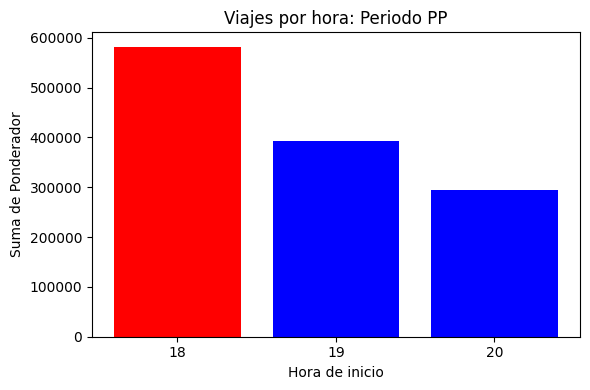

In [106]:
colores = ["red" if bar == pp_peak else "blue" for bar in suma_por_hora_pp.index]

plt.figure(figsize=(6, 4))
plt.bar(suma_por_hora_pp.index.astype(str), suma_por_hora_pp.values, color=colores)
plt.xlabel("Hora de inicio")
plt.ylabel("Suma de Ponderador")
plt.title("Viajes por hora: Periodo PP")
plt.tight_layout()
plt.show()

In [107]:
pp_peak_factor = pp_peak_value / pp_total
print("peak factor de PP: ", pp_peak_factor)

peak factor de PP:  0.4587552899820927


## Análisis de LN: Late Night

In [108]:
ln = matriz_global[matriz_global["Periodo"] == "LN"]

suma_por_hora_ln = ln.groupby("Hora_inicio")["Ponderador"].sum()
ln_total = suma_por_hora_ln.sum()
print("Total de viajes en LN:", ln_total)
print(suma_por_hora_ln)
ln_peak = suma_por_hora_ln.idxmax()
ln_peak_value = suma_por_hora_ln.max()

print("Hora pico: ", ln_peak,", con ", ln_peak_value, "  viajes.")

Total de viajes en LN: 281863
Hora_inicio
21    150350
22     78203
23     53310
Name: Ponderador, dtype: int64
Hora pico:  21 , con  150350   viajes.


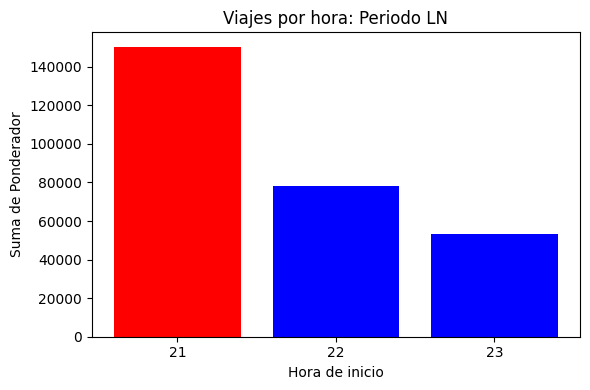

In [109]:
colores = ["red" if bar == ln_peak else "blue" for bar in suma_por_hora_ln.index]

plt.figure(figsize=(6, 4))
plt.bar(suma_por_hora_ln.index.astype(str), suma_por_hora_ln.values, color=colores)
plt.xlabel("Hora de inicio")
plt.ylabel("Suma de Ponderador")
plt.title("Viajes por hora: Periodo LN")
plt.tight_layout()
plt.show()

In [110]:
ln_peak_factor = ln_peak_value / ln_total
print("peak factor de LN: ", ln_peak_factor)

peak factor de LN:  0.5334151697810638


# Análisis global

In [111]:
resumen = pd.DataFrame({
    "Periodo": ["EM", "AP", "LM", "EA", "PP", "LN"],
    "Hora pico": [em_peak, ap_peak, lm_peak, ea_peak, pp_peak, ln_peak],
    "Número de viajes en hora pico": [em_peak_value, ap_peak_value, lm_peak_value, ea_peak_value, pp_peak_value, ln_peak_value],
    "Total de viajes por periodo": [em_total, ap_total, lm_total, ea_total, pp_total, ln_total],
    "Peak factor por periodo": [em_peak_factor, ap_peak_factor, lm_peak_factor, ea_peak_factor, pp_peak_factor, ln_peak_factor],
})

resumen

,Periodo,Hora pico,Número de viajes en hora pico,Total de viajes por periodo,Peak factor por periodo
0,EM,0,12571,40261,0.312238
1,AP,7,616322,1713959,0.359590
2,LM,9,300174,802885,0.373869
3,EA,13,431126,2374480,0.181566
4,PP,18,581793,1268199,0.458755
5,LN,21,150350,281863,0.533415


In [112]:
suma_por_hora_dia = matriz_global.groupby("Hora_inicio")["Ponderador"].sum()
print("Total de viajes: ",suma_por_hora_dia.sum())

Total de viajes:  6481647


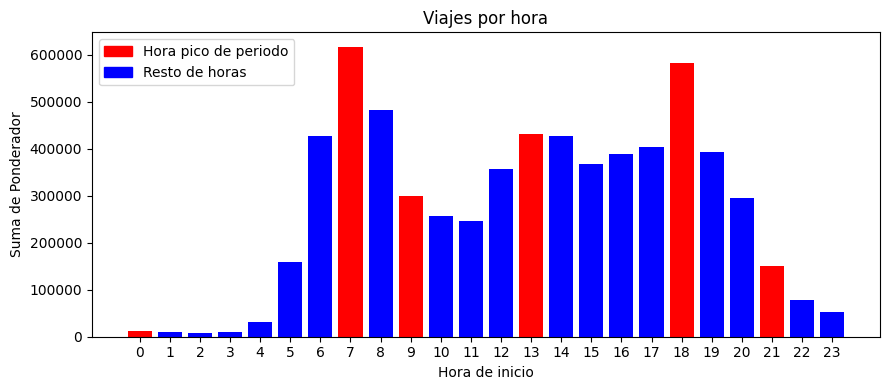

In [113]:
horas_pico = {em_peak, ap_peak, lm_peak, ea_peak, pp_peak, ln_peak}

colores = ["red" if h in horas_pico else "blue" for h in suma_por_hora_dia.index]

plt.figure(figsize=(9, 4))
plt.bar(suma_por_hora_dia.index.astype(str), suma_por_hora_dia.values, color=colores)
plt.xlabel("Hora de inicio")
plt.ylabel("Suma de Ponderador")
plt.title("Viajes por hora")
plt.legend(handles=[Patch(color="red", label="Hora pico de periodo"),
                     Patch(color="blue", label="Resto de horas")])
plt.tight_layout()
plt.show()

Se distingue como a las 7 AM y 6 PM se forman los picos más altos, pudiera asociarse a las horas de salidad de casa y regreso a casa, relacionado con las horas entrada y salida de la mayoría de los trabajos.